In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True).round(3)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nNull values: {df.isnull().sum().sum()}")

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition rate: Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64

Data types:
int64    26
str       9
Name: count, dtype: int64

Null values: 0


In [3]:
con = duckdb.connect()
con.register('employees', df)

profile = con.execute("""
SELECT
    COUNT(*)                                          AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS attrited,
    ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' 
        THEN 1 ELSE 0 END) / COUNT(*), 1)            AS attrition_rate_pct,
    ROUND(AVG(Age), 1)                               AS avg_age,
    ROUND(AVG(MonthlyIncome), 0)                     AS avg_monthly_income,
    ROUND(AVG(YearsAtCompany), 1)                    AS avg_tenure_years,
    COUNT(DISTINCT Department)                        AS departments,
    COUNT(DISTINCT JobRole)                           AS job_roles
FROM employees
""").df()

print(profile.to_string())

# Attrition by department
dept = con.execute("""
SELECT
    Department,
    COUNT(*)                                           AS total,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS attrited,
    ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes'
        THEN 1 ELSE 0 END) / COUNT(*), 1)             AS attrition_rate_pct
FROM employees
GROUP BY Department
ORDER BY attrition_rate_pct DESC
""").df()

print("\nAttrition by department:")
print(dept.to_string(index=False))

   total_employees  attrited  attrition_rate_pct  avg_age  avg_monthly_income  avg_tenure_years  departments  job_roles
0             1470     237.0                16.1     36.9              6503.0               7.0            3          9

Attrition by department:
            Department  total  attrited  attrition_rate_pct
                 Sales    446      92.0                20.6
       Human Resources     63      12.0                19.0
Research & Development    961     133.0                13.8


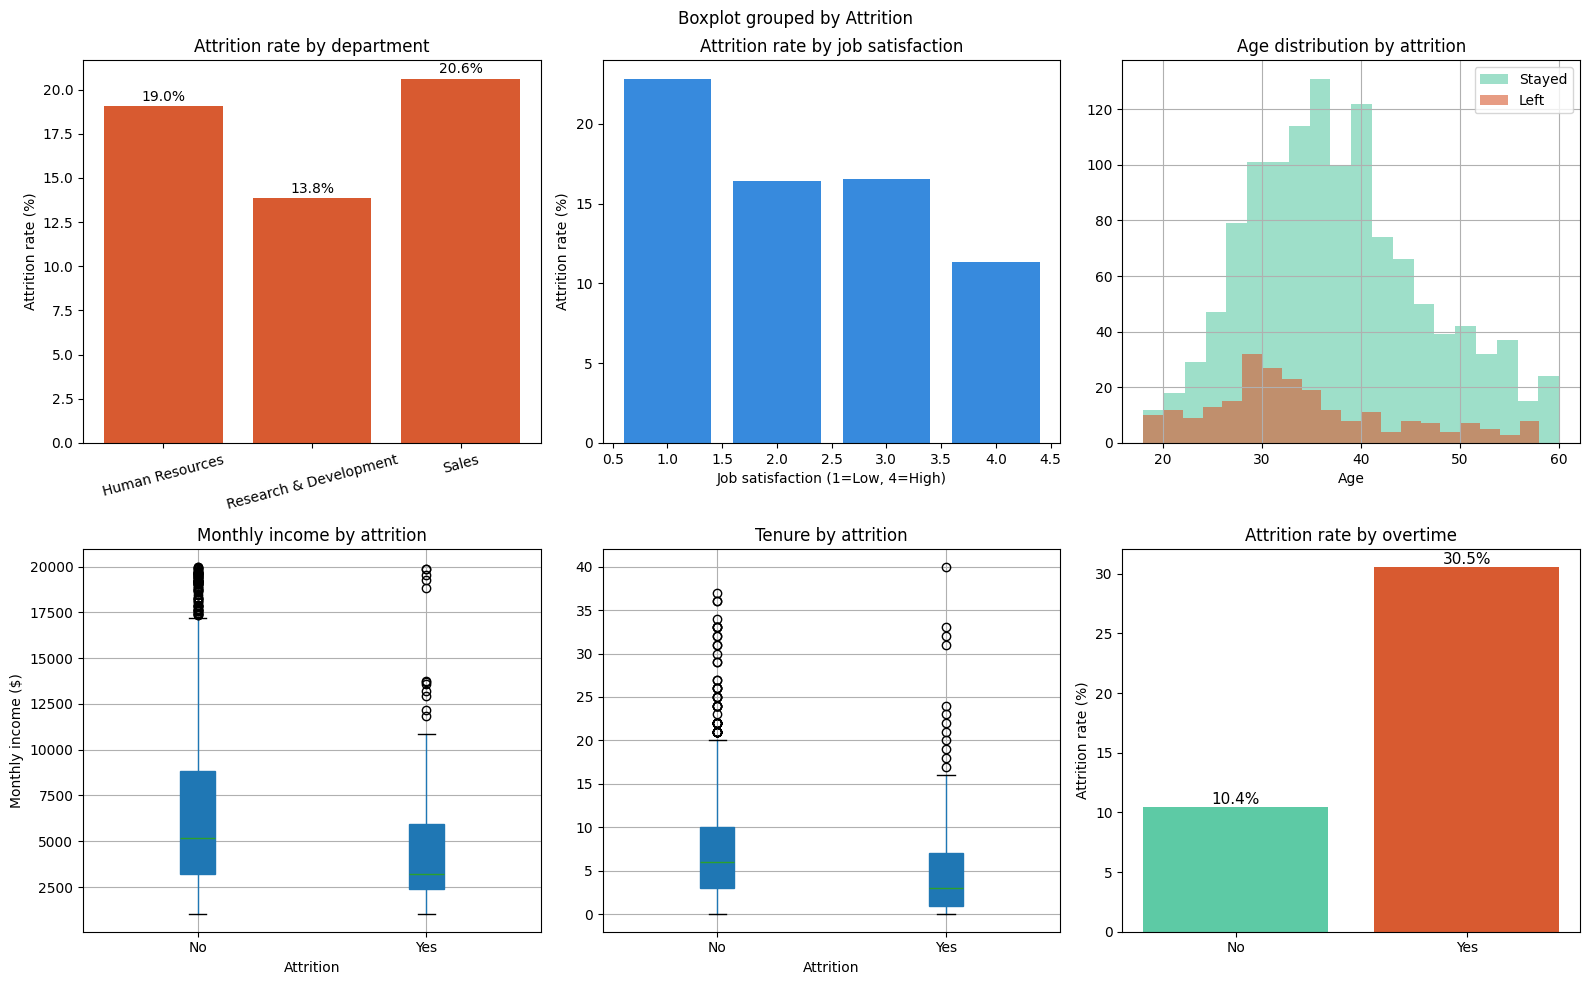

In [4]:
# Convert target to binary
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Attrition EDA — Key Drivers', fontsize=14, fontweight='bold')

# 1. Attrition rate by department
dept_rate = df.groupby('Department')['Attrition_Binary'].mean() * 100
axes[0,0].bar(dept_rate.index, dept_rate.values, color='#D85A30')
axes[0,0].set_title('Attrition rate by department')
axes[0,0].set_ylabel('Attrition rate (%)')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(dept_rate.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

# 2. Attrition by job satisfaction
sat_rate = df.groupby('JobSatisfaction')['Attrition_Binary'].mean() * 100
axes[0,1].bar(sat_rate.index, sat_rate.values, color='#378ADD')
axes[0,1].set_title('Attrition rate by job satisfaction')
axes[0,1].set_xlabel('Job satisfaction (1=Low, 4=High)')
axes[0,1].set_ylabel('Attrition rate (%)')

# 3. Age distribution by attrition
df[df['Attrition']=='No']['Age'].hist(ax=axes[0,2], alpha=0.6,
    color='#5DCAA5', label='Stayed', bins=20)
df[df['Attrition']=='Yes']['Age'].hist(ax=axes[0,2], alpha=0.6,
    color='#D85A30', label='Left', bins=20)
axes[0,2].set_title('Age distribution by attrition')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# 4. Monthly income by attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1,0],
           patch_artist=True)
axes[1,0].set_title('Monthly income by attrition')
axes[1,0].set_xlabel('Attrition')
axes[1,0].set_ylabel('Monthly income ($)')
plt.sca(axes[1,0])
plt.title('Monthly income by attrition')

# 5. Years at company by attrition
df.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1,1],
           patch_artist=True)
axes[1,1].set_title('Tenure by attrition')
axes[1,1].set_xlabel('Attrition')
plt.sca(axes[1,1])
plt.title('Tenure by attrition')

# 6. Overtime by attrition
ot_rate = df.groupby('OverTime')['Attrition_Binary'].mean() * 100
axes[1,2].bar(ot_rate.index, ot_rate.values,
              color=['#5DCAA5', '#D85A30'])
axes[1,2].set_title('Attrition rate by overtime')
axes[1,2].set_ylabel('Attrition rate (%)')
for i, v in enumerate(ot_rate.values):
    axes[1,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_feat = df.copy()

# 1. Compensation ratio vs department median
dept_median = df_feat.groupby('Department')['MonthlyIncome'].transform('median')
df_feat['CompRatio'] = df_feat['MonthlyIncome'] / dept_median

# 2. Tenure bucket
df_feat['TenureBucket'] = pd.cut(
    df_feat['YearsAtCompany'],
    bins=[0, 1, 3, 7, 15, 100],
    labels=['<1yr', '1-3yr', '3-7yr', '7-15yr', '15yr+']
)

# 3. Promotion recency score (years since last promotion)
df_feat['PromotionRecency'] = df_feat['YearsSinceLastPromotion']

# 4. Satisfaction composite score
df_feat['SatisfactionScore'] = (
    df_feat['JobSatisfaction'] +
    df_feat['EnvironmentSatisfaction'] +
    df_feat['RelationshipSatisfaction']
) / 3

# 5. Work-life balance flag
df_feat['WorkLifeFlag'] = (df_feat['WorkLifeBalance'] <= 2).astype(int)

# 6. Income per year of experience
df_feat['IncomePerYearExp'] = (
    df_feat['MonthlyIncome'] /
    (df_feat['TotalWorkingYears'] + 1)
)

print("New features created:")
new_cols = ['CompRatio','TenureBucket','PromotionRecency',
            'SatisfactionScore','WorkLifeFlag','IncomePerYearExp']
print(df_feat[new_cols].describe().round(2))
print(f"\nDataframe shape: {df_feat.shape}")

New features created:
       CompRatio  PromotionRecency  SatisfactionScore  WorkLifeFlag  \
count    1470.00           1470.00            1470.00       1470.00   
mean        1.38              2.19               2.72          0.29   
std         1.04              3.22               0.63          0.45   
min         0.18              0.00               1.00          0.00   
25%         0.66              0.00               2.33          0.00   
50%         1.00              1.00               2.67          0.00   
75%         1.65              3.00               3.33          1.00   
max         5.07             15.00               4.00          1.00   

       IncomePerYearExp  
count           1470.00  
mean             587.58  
std              284.65  
min               95.29  
25%              374.23  
50%              549.22  
75%              738.30  
max             1904.00  

Dataframe shape: (1470, 42)


In [6]:
from sklearn.preprocessing import LabelEncoder

df_model = df_feat.copy()

# Drop columns that are constants or leak the target
drop_cols = [
    'EmployeeCount',    # always 1
    'Over18',           # always Y
    'StandardHours',    # always 80
    'EmployeeNumber',   # just an ID
    'Attrition',        # original target string
    'TenureBucket'      # already encoded numerically
]
df_model = df_model.drop(columns=drop_cols)

# Encode binary/ordinal categoricals
le = LabelEncoder()
cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Final feature matrix
X = df_model.drop(columns=['Attrition_Binary'])
y = df_model['Attrition_Binary']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Attrition rate: {y.mean()*100:.1f}%")
print(f"\nFeatures ({len(X.columns)}):\n{X.columns.tolist()}")

Feature matrix shape: (1470, 35)
Target distribution:
Attrition_Binary
0    1233
1     237
Name: count, dtype: int64
Attrition rate: 16.1%

Features (35):
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'CompRatio', 'PromotionRecency', 'SatisfactionScore', 'WorkLifeFlag', 'IncomePerYearExp']


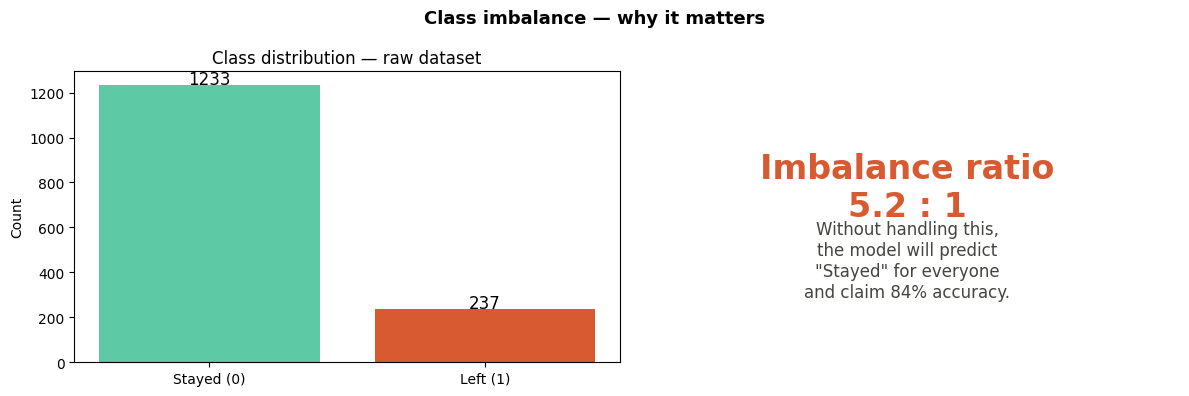

Majority class (Stayed): 1233 (83.9%)
Minority class (Left):   237 (16.1%)
Imbalance ratio: 5.2:1

Baseline accuracy (predict all Stayed): 83.9%
This is why accuracy is a misleading metric here.
We will optimise for Recall instead.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = y.value_counts()
axes[0].bar(['Stayed (0)', 'Left (1)'], counts.values,
            color=['#5DCAA5', '#D85A30'])
axes[0].set_title('Class distribution — raw dataset')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12)

# Imbalance ratio
ratio = counts[0] / counts[1]
axes[1].text(0.5, 0.6, f'Imbalance ratio\n{ratio:.1f} : 1',
             ha='center', va='center', fontsize=24,
             fontweight='bold', color='#D85A30',
             transform=axes[1].transAxes)
axes[1].text(0.5, 0.35,
             f'Without handling this,\nthe model will predict\n'
             f'"Stayed" for everyone\nand claim {(1-y.mean())*100:.0f}% accuracy.',
             ha='center', va='center', fontsize=12,
             color='#444441', transform=axes[1].transAxes)
axes[1].axis('off')

plt.suptitle('Class imbalance — why it matters', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_class_imbalance.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f"Majority class (Stayed): {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Minority class (Left):   {counts[1]} ({counts[1]/len(y)*100:.1f}%)")
print(f"Imbalance ratio: {ratio:.1f}:1")
print(f"\nBaseline accuracy (predict all Stayed): {(1-y.mean())*100:.1f}%")
print("This is why accuracy is a misleading metric here.")
print("We will optimise for Recall instead.")